# Notebook 06 — Current Environment and Portfolio Scenario Analysis

## Purpose
Assess the current UK gilt market environment relative to the historical cycle.
Frame portfolio positioning implications through three macro scenarios.

## Research Question
Where are UK gilts now, what are inflation expectations pricing, 
and how does the current fiscal position compare to the pre-Truss period?

## Key Analysis
- Current yield curve snapshot vs historical range
- Current breakeven inflation — what is the market pricing for 5yr and 10yr inflation?
- UK fiscal position: debt/GDP and deficit trajectory vs pre-Truss baseline
- Portfolio scenario analysis:
  - **Soft landing**: inflation re-anchors, BoE cuts to neutral, curve bull steepens
  - **Stagflation re-emergence**: inflation rebounds, BoE on hold, curve bear flattens
  - **Fiscal stress**: issuance overwhelms demand, term premium widens, bear steepens
- Gilt positioning implications by maturity under each scenario

## Reads from
All processed data files (current-dated pulls)

In [4]:
# ============================================================
# SETUP — WORKING DIRECTORY, IMPORTS, LOAD DATA
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

# Fix working directory
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

print(f"Working directory: {os.getcwd()}")

# Load all relevant processed data
gilts_nominal = pd.read_csv('data/processed/uk_gilts_nominal.csv',
                             index_col=0, parse_dates=True)
gilts_nominal.index.name = 'date'

gilts_real = pd.read_csv('data/processed/uk_gilts_real.csv',
                          index_col=0, parse_dates=True)
gilts_real.index.name = 'date'

inflation_curve = pd.read_csv('data/processed/uk_inflation_curve.csv',
                               index_col=0, parse_dates=True)
inflation_curve.index.name = 'date'

us_treasuries = pd.read_csv('data/processed/us_treasuries.csv',
                              index_col=0, parse_dates=True)
us_treasuries.index.name = 'date'

cpi = pd.read_csv('data/processed/ons_cpi.csv',
                   index_col=0, parse_dates=True)
cpi.index.name = 'date'

# Confirm loaded
for name, df in [('UK nominal gilts', gilts_nominal),
                 ('UK real gilts',    gilts_real),
                 ('Inflation curve',  inflation_curve),
                 ('US Treasuries',    us_treasuries),
                 ('CPI',             cpi)]:
    print(f"{name:<22} {df.shape[0]:>5} rows  "
          f"{df.index[0].date()} to {df.index[-1].date()}")

# Current date — most recent observation in gilt data
CURRENT_DATE = gilts_nominal.index[-1]
print(f"\nMost recent gilt observation: {CURRENT_DATE.strftime('%d %b %Y')}")

# Key historical reference dates for comparison

PRE_TRUSS_CLEAN = pd.Timestamp('2022-08-01')  
# Clean pre-Truss baseline — before Truss-specific fiscal risk began pricing.
# 30yr yield ~2.43%. Used as primary pre-crisis reference.

PRE_TRUSS_DAY   = pd.Timestamp('2022-09-22')  
# Day before mini-budget — already 56bps above Aug baseline.
# Market had partially priced fiscal risk via OBR announcement removal.
# Secondary reference only — not a clean baseline.

TRUSS_PEAK      = pd.Timestamp('2022-09-27')  
# Peak of 30yr gilt yield at ~4.85%. BoE intervened following morning.
# Note: other maturities peaked on different dates.

POST_TRUSS      = pd.Timestamp('2022-10-31')  
# Post-resolution — Truss resigned 20 Oct, Sunak PM, Hunt budget reversal.
# By this date 30yr yield had fully reversed to ~3.49% — below pre-budget level.
# Represents complete market resolution of the episode.

YIELD_PEAK      = pd.Timestamp('2023-10-06')  
# Peak of 10yr gilt yield at ~4.7% — later than BoE rate peak.
# BoE Bank Rate peaked at 5.25% on 3 Aug 2023 but gilt yields
# continued rising as markets digested higher-for-longer guidance.
# Distinction important — Bank Rate peak ≠ gilt yield peak.

CUTS_BEGIN      = pd.Timestamp('2024-08-01')  
# BoE first rate cut — 1 August 2024. Start of easing cycle.
# Note: market was pricing cuts well before this date.
# Gilt yields had already begun falling in anticipation.

print("Reference dates confirmed:")
dates = {
    'Pre-Truss clean baseline': PRE_TRUSS_CLEAN,
    'Pre-Truss day (contaminated)': PRE_TRUSS_DAY,
    'Truss peak (30yr)': TRUSS_PEAK,
    'Post-Truss resolution': POST_TRUSS,
    'Gilt yield peak (10yr)': YIELD_PEAK,
    'BoE cuts begin': CUTS_BEGIN,
    'Current (latest data)': CURRENT_DATE,
}
for label, date in dates.items():
    idx = gilts_nominal.index.get_indexer([date], method='nearest')[0]
    row = gilts_nominal.iloc[idx]
    print(f"  {label:<30} {date.strftime('%d %b %Y')}  "
          f"2yr: {row['uk_2yr']:.2f}%  "
          f"10yr: {row['uk_10yr']:.2f}%  "
          f"30yr: {row['uk_30yr']:.2f}%")

Working directory: C:\Users\tomsu\Documents\Graduate Jobs\CV PROJECTS\uk-gilt-market-analysis
UK nominal gilts        2589 rows  2016-01-04 to 2026-03-31
UK real gilts           2589 rows  2016-01-04 to 2026-03-31
Inflation curve         2589 rows  2016-01-04 to 2026-03-31
US Treasuries           2675 rows  2016-01-01 to 2026-04-02
CPI                      122 rows  2016-01-01 to 2026-02-01

Most recent gilt observation: 31 Mar 2026
Reference dates confirmed:
  Pre-Truss clean baseline       01 Aug 2022  2yr: 1.67%  10yr: 1.85%  30yr: 2.27%
  Pre-Truss day (contaminated)   22 Sep 2022  2yr: 3.52%  10yr: 3.55%  30yr: 3.72%
  Truss peak (30yr)              27 Sep 2022  2yr: 4.53%  10yr: 4.43%  30yr: 4.85%
  Post-Truss resolution          31 Oct 2022  2yr: 3.34%  10yr: 3.62%  30yr: 3.49%
  Gilt yield peak (10yr)         06 Oct 2023  2yr: 4.61%  10yr: 4.58%  30yr: 5.04%
  BoE cuts begin                 01 Aug 2024  2yr: 3.92%  10yr: 3.86%  30yr: 4.50%
  Current (latest data)          31 Ma

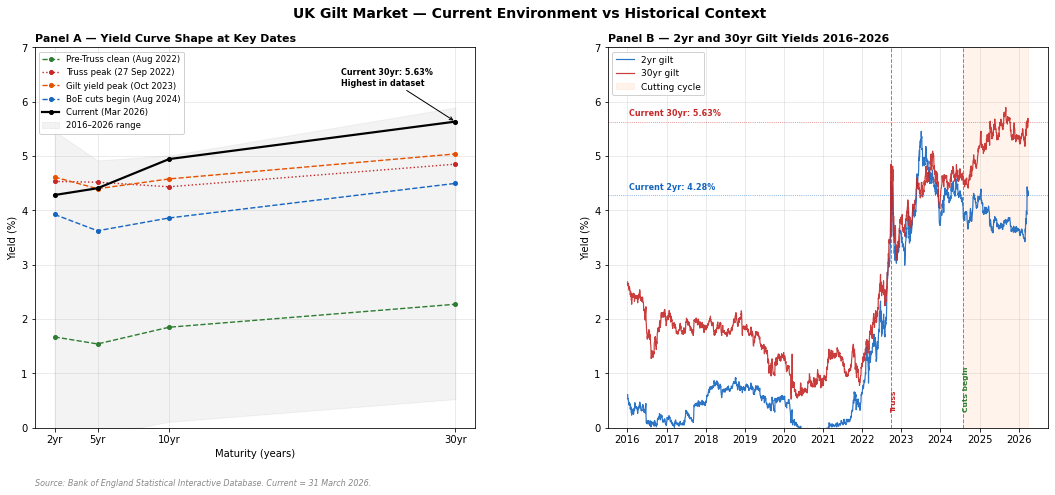

Chart saved.


In [5]:
# ============================================================
# CURRENT YIELD CURVE SNAPSHOT VS HISTORICAL RANGE
# ============================================================

# Calculate historical range across full sample
hist_min  = gilts_nominal.min()
hist_max  = gilts_nominal.max()
hist_mean = gilts_nominal.mean()

# Extract yields at key dates
def get_yields(date):
    idx = gilts_nominal.index.get_indexer([date], method='nearest')[0]
    return gilts_nominal.iloc[idx]

maturities    = [2, 5, 10, 30]
maturity_cols = ['uk_2yr', 'uk_5yr', 'uk_10yr', 'uk_30yr']

current      = get_yields(CURRENT_DATE)
pre_truss    = get_yields(PRE_TRUSS_CLEAN)
truss_peak   = get_yields(TRUSS_PEAK)
yield_peak   = get_yields(YIELD_PEAK)
cuts_begin   = get_yields(CUTS_BEGIN)

fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor='white')
fig.subplots_adjust(top=0.88, wspace=0.30, left=0.07, right=0.95)
fig.suptitle('UK Gilt Market — Current Environment vs Historical Context',
             fontsize=14, fontweight='bold', y=0.96)

# --- LEFT PANEL: yield curve shapes at key dates ---
ax1 = axes[0]
ax1.set_facecolor('white')

# Historical range shading
ax1.fill_between(maturities,
                 [hist_min[col] for col in maturity_cols],
                 [hist_max[col] for col in maturity_cols],
                 alpha=0.12, color='#9E9E9E', label='2016–2026 range')

# Key curves
curves = [
    (pre_truss,  '#2E7D32', '--', 'Pre-Truss clean (Aug 2022)'),
    (truss_peak, '#C62828', ':',  'Truss peak (27 Sep 2022)'),
    (yield_peak, '#E65100', '--', 'Gilt yield peak (Oct 2023)'),
    (cuts_begin, '#1565C0', '--', 'BoE cuts begin (Aug 2024)'),
    (current,    '#000000', '-',  f'Current ({CURRENT_DATE.strftime("%b %Y")})'),
]

for data, color, style, label in curves:
    vals = [data[col] for col in maturity_cols]
    lw   = 2.2 if style == '-' else 1.4
    ax1.plot(maturities, vals, color=color, linestyle=style,
             linewidth=lw, label=label, marker='o', markersize=4)

ax1.set_title('Panel A — Yield Curve Shape at Key Dates',
              fontsize=11, fontweight='bold', loc='left')
ax1.set_xlabel('Maturity (years)', fontsize=10)
ax1.set_ylabel('Yield (%)', fontsize=10)
ax1.set_xticks(maturities)
ax1.set_xticklabels(['2yr', '5yr', '10yr', '30yr'])
ax1.legend(fontsize=8.5, framealpha=0.9)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 7)

# Annotate current 30yr
ax1.annotate(f'Current 30yr: {current["uk_30yr"]:.2f}%\nHighest in dataset',
             xy=(30, current['uk_30yr']),
             xytext=(22, 6.3),
             fontsize=8, color='black', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='black', lw=1.0))

# --- RIGHT PANEL: time series of 2yr and 30yr with current highlighted ---
ax2 = axes[1]
ax2.set_facecolor('white')

ax2.plot(gilts_nominal.index.to_pydatetime(),
         gilts_nominal['uk_2yr'].values,
         color='#1565C0', linewidth=1.2, label='2yr gilt', alpha=0.9)
ax2.plot(gilts_nominal.index.to_pydatetime(),
         gilts_nominal['uk_30yr'].values,
         color='#C62828', linewidth=1.2, label='30yr gilt', alpha=0.9)

# Shade current period
ax2.axvspan(CUTS_BEGIN, CURRENT_DATE,
            alpha=0.08, color='#FF6F00', label='Cutting cycle')

# Current level lines
ax2.axhline(y=current['uk_2yr'],  color='#1565C0',
            linewidth=0.8, linestyle=':', alpha=0.7)
ax2.axhline(y=current['uk_30yr'], color='#C62828',
            linewidth=0.8, linestyle=':', alpha=0.7)

# Annotate current levels
ax2.text(gilts_nominal.index[10], current['uk_2yr'] + 0.1,
         f'Current 2yr: {current["uk_2yr"]:.2f}%',
         fontsize=8, color='#1565C0', fontweight='bold')
ax2.text(gilts_nominal.index[10], current['uk_30yr'] + 0.1,
         f'Current 30yr: {current["uk_30yr"]:.2f}%',
         fontsize=8, color='#C62828', fontweight='bold')

# Key event lines
for label, date, color in [
    ('Truss', TRUSS_PEAK, '#C62828'),
    ('Cuts begin', CUTS_BEGIN, '#2E7D32'),
]:
    ax2.axvline(x=date, color=color, linestyle='--',
                linewidth=1.0, alpha=0.7)
    ax2.text(date, 0.3, label, fontsize=7.5, color=color,
             fontweight='bold', rotation=90, va='bottom')

ax2.set_title('Panel B — 2yr and 30yr Gilt Yields 2016–2026',
              fontsize=11, fontweight='bold', loc='left')
ax2.set_ylabel('Yield (%)', fontsize=10)
ax2.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.set_ylim(0, 7)

fig.text(0.07, 0.01,
         'Source: Bank of England Statistical Interactive Database. '
         'Current = 31 March 2026.',
         fontsize=8, color='#888888', style='italic')

plt.savefig('outputs/charts/06_current_environment.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Chart saved.")

In [7]:
# ============================================================
# CURRENT ENVIRONMENT SUMMARY TABLE
# ============================================================

def get_yields(date):
    idx = gilts_nominal.index.get_indexer([date], method='nearest')[0]
    return gilts_nominal.iloc[idx]

def get_inflation(date):
    idx = inflation_curve.index.get_indexer([date], method='nearest')[0]
    return inflation_curve.iloc[idx]

def get_real(date):
    idx = gilts_real.index.get_indexer([date], method='nearest')[0]
    return gilts_real.iloc[idx]

# Key reference dates
ref_dates = {
    'Pre-Truss clean (Aug 2022)': PRE_TRUSS_CLEAN,
    'Truss peak (Sep 2022)':      TRUSS_PEAK,
    'Gilt yield peak (Oct 2023)': YIELD_PEAK,
    'BoE cuts begin (Aug 2024)':  CUTS_BEGIN,
    'Current (Mar 2026)':         CURRENT_DATE,
}

print("UK GILT MARKET — CURRENT ENVIRONMENT SUMMARY")
print("=" * 85)
print(f"{'Date':<28} {'2yr':>6} {'10yr':>6} {'30yr':>6} "
      f"{'2/10 sprd':>10} {'BE 10yr':>8} {'Real 10yr':>10}")
print("-" * 85)

for label, date in ref_dates.items():
    nom  = get_yields(date)
    inf  = get_inflation(date)
    real = get_real(date)

    spread_2_10 = nom['uk_10yr'] - nom['uk_2yr']
    be_10yr     = inf['uk_inf_10yr']
    real_10yr   = real['uk_real_10yr']

    print(f"{label:<28} "
          f"{nom['uk_2yr']:>6.2f} "
          f"{nom['uk_10yr']:>6.2f} "
          f"{nom['uk_30yr']:>6.2f} "
          f"{spread_2_10:>+10.2f} "
          f"{be_10yr:>8.2f} "
          f"{real_10yr:>10.2f}")

print("-" * 85)
print(f"\nAll yields in %. BE = breakeven inflation. Real = real yield.")
print(f"2/10 spread: positive = normal curve, negative = inverted.")

UK GILT MARKET — CURRENT ENVIRONMENT SUMMARY
Date                            2yr   10yr   30yr  2/10 sprd  BE 10yr  Real 10yr
-------------------------------------------------------------------------------------
Pre-Truss clean (Aug 2022)     1.67   1.85   2.27      +0.18     3.60      -1.75
Truss peak (Sep 2022)          4.53   4.43   4.85      -0.10     3.37       1.06
Gilt yield peak (Oct 2023)     4.61   4.58   5.04      -0.03     3.56       1.01
BoE cuts begin (Aug 2024)      3.92   3.86   4.50      -0.06     3.47       0.39
Current (Mar 2026)             4.28   4.94   5.63      +0.66     3.53       1.42
-------------------------------------------------------------------------------------

All yields in %. BE = breakeven inflation. Real = real yield.
2/10 spread: positive = normal curve, negative = inverted.


## Portfolio Scenario Analysis

Three scenarios for the UK gilt market over a 12-month horizon from March 2026. 
Yield implications and positioning by maturity under each macro backdrop.

Scenarios are framed around macro dynamics rather than specific geopolitical triggers.
Geopolitical uncertainty — including energy market disruption risk — is noted as a
component of the current term premium without attribution to specific events.

*Illustrative yield moves only — not forecasts.*

In [15]:
# ============================================================
# PORTFOLIO SCENARIO ANALYSIS
# ============================================================

print("UK GILT MARKET — PORTFOLIO SCENARIO ANALYSIS")
print("As of March 2026 | Horizon: 12 months")
print()
print("Note: UK CPI stood at 2.8% in February 2026. The soft landing")
print("scenario assumes further disinflation toward 2.5% by end-2026")
print("— plausible but not certain given persistent services inflation")
print("and energy price uncertainty. A growth shock scenario (aggressive")
print("BoE easing driving broad gilt rally) is not modelled explicitly")
print("but would represent the reverse of the fiscal stress scenario.")
print("=" * 85)

current_yields = {
    '2yr':  4.28,
    '5yr':  4.41,
    '10yr': 4.94,
    '30yr': 5.63,
}

scenarios = [
    {
        'name':      'SCENARIO 1 — SOFT LANDING',
        'prob':      'Base case',
        'macro':     ('Inflation falls toward 2.5% CPI by end-2026 as services '
                      'inflation moderates. BoE cuts cautiously to neutral '
                      '(~3.25-3.50%) by mid-2027. UK growth modest but positive. '
                      'Fiscal position broadly stable.'),
        'curve':     'Bull steepening — short end falls faster than long end',
        'moves':     {'2yr': -50, '5yr': -35, '10yr': -20, '30yr': +10},
        'anchor':    ('Short end move consistent with pricing ~50bps of '
                      'additional BoE cuts toward neutral. More cautious than '
                      'full re-anchoring to 2% given CPI at 2.8% in Feb 2026. '
                      'Long end remains elevated — term premium persists, '
                      'consistent with 2024 pattern where long yields rose '
                      'despite BoE cutting.'),
        'position':  ('Long 2yr and 5yr — maximum policy sensitivity. '
                      'Underweight 30yr — term premium limits long-end rally. '
                      'Neutral linkers — partial disinflation reduces but does '
                      'not eliminate breakeven attractiveness.'),
        'risk':      ('Inflation proves stickier than expected — '
                      'BoE pauses earlier than priced. '
                      'Services inflation or energy shock delays disinflation.'),
    },
    {
        'name':      'SCENARIO 2 — STAGFLATION RE-EMERGENCE',
        'prob':      'Downside risk',
        'macro':     ('Inflation rebounds to 4-5% driven by energy shock or '
                      'persistent services inflation. BoE forced to pause or '
                      'reverse cutting cycle. UK growth stagnates. '
                      'Fiscal position deteriorates as tax revenues disappoint.'),
        'curve':     ('Bear flattening — short end rises on policy reversal, '
                      'long end rises less as growth fears cap the move'),
        'moves':     {'2yr': +75, '5yr': +50, '10yr': +35, '30yr': +20},
        'anchor':    ('Moves calibrated to approximately one-third of the '
                      '2021-2022 inflation re-emergence episode in our dataset, '
                      'reflecting a less severe shock from an already '
                      'elevated yield starting point. From current levels '
                      'a full repeat of 2021-2022 is unlikely — '
                      'the hiking cycle has already done significant work.'),
        'position':  ('Short duration across the curve. '
                      'Overweight index-linked gilts — breakevens at 3.53% '
                      'likely underpricing re-emergence. '
                      'Short GBPUSD — stagflation negative for sterling.'),
        'risk':      ('Growth deterioration forces BoE to cut despite '
                      'inflation — stagflation dilemma with no good '
                      'policy response.'),
    },
    {
        'name':      'SCENARIO 3 — FISCAL STRESS',
        'prob':      'Tail risk',
        'macro':     ('Gilt issuance overwhelms demand as fiscal deficit widens. '
                      'Term premium reprices sharply at the long end. '
                      'OBR forecasts deteriorate. International investors '
                      'demand higher compensation for UK sovereign risk. '
                      'BoE continues cutting short rates but cannot suppress '
                      'long-end yields.'),
        'curve':     ('Bear steepening — short end anchored by BoE cuts, '
                      'long end repriced sharply by fiscal risk premium'),
        'moves':     {'2yr': -25, '5yr': +15, '10yr': +60, '30yr': +100},
        'anchor':    ('Long-end move motivated by two sources: '
                      '(1) Truss episode — 30yr moved ~258bps from the clean '
                      'pre-Truss baseline to peak. Scenario uses ~40% of that '
                      'move reflecting a slow grind rather than sudden shock. '
                      '(2) Notebook 04 OLS regression residuals showing '
                      'persistent 60-107bp unexplained UK fiscal risk premium '
                      'post-2022 — scenario assumes this premium widens further.'),
        'position':  ('Maximum short duration at the long end. '
                      'Overweight 2yr vs 30yr — steepening trade. '
                      'Short GBPUSD — fiscal stress historically negative '
                      'for sterling as shown in notebook 04 regression.'),
        'risk':      ('Fiscal consolidation announcement could rapidly '
                      'reverse the move — as seen in October 2022 post-Truss. '
                      'BoE intervention in gilt market cannot be ruled out '
                      'if dysfunction re-emerges.'),
    },
]

for s in scenarios:
    print(f"\n{'='*85}")
    print(f"{s['name']}  [{s['prob']}]")
    print(f"{'-'*85}")
    print(f"Macro:         {s['macro']}")
    print(f"Curve dynamic: {s['curve']}")
    print()
    print(f"  {'Maturity':<8} {'Current%':>9} {'Move':>8} {'Implied%':>10}")
    print(f"  {'-'*40}")

    for mat in ['2yr', '5yr', '10yr', '30yr']:
        move    = s['moves'][mat]
        current = current_yields[mat]
        implied = current + move / 100
        print(f"  {mat:<8} {current:>9.2f} {move:>+7}bp {implied:>10.2f}")

    print(f"\n  Calibration: {s['anchor']}")
    print(f"  Positioning: {s['position']}")
    print(f"  Key risk:    {s['risk']}")

print(f"\n{'='*85}")
print(f"\nMethodology note: Yield moves are judgement-based scenario estimates")
print(f"informed by historical episodes in the 2016-2026 dataset.")
print(f"Empirical estimation of yield-policy betas was attempted but")
print(f"produced statistically unreliable results (R²=0.03-0.07),")
print(f"reflecting that monetary policy explains only 3-7% of monthly")
print(f"gilt yield variation at this frequency. Scenario moves use")
print(f"historical anchors and regression residuals instead.")
print(f"Not forecasts. Current yields as of 31 March 2026.")

UK GILT MARKET — PORTFOLIO SCENARIO ANALYSIS
As of March 2026 | Horizon: 12 months

Note: UK CPI stood at 2.8% in February 2026. The soft landing
scenario assumes further disinflation toward 2.5% by end-2026
— plausible but not certain given persistent services inflation
and energy price uncertainty. A growth shock scenario (aggressive
BoE easing driving broad gilt rally) is not modelled explicitly
but would represent the reverse of the fiscal stress scenario.

SCENARIO 1 — SOFT LANDING  [Base case]
-------------------------------------------------------------------------------------
Macro:         Inflation falls toward 2.5% CPI by end-2026 as services inflation moderates. BoE cuts cautiously to neutral (~3.25-3.50%) by mid-2027. UK growth modest but positive. Fiscal position broadly stable.
Curve dynamic: Bull steepening — short end falls faster than long end

  Maturity  Current%     Move   Implied%
  ----------------------------------------
  2yr           4.28     -50bp       3.78

## Key Findings — Current Environment and Scenario Analysis

### Current Environment — March 2026

The UK gilt market presents a striking paradox: the BoE is actively cutting
rates yet long-end yields are at their highest level in the full 2016–2026
dataset. The 30yr gilt at 5.63% exceeds both the Truss peak (4.85%) and
the October 2023 gilt yield peak (5.04%).

**Key metrics vs historical reference points:**

| | Pre-Truss Aug 2022 | Truss Peak Sep 2022 | Yield Peak Oct 2023 | Current Mar 2026 |
|---|---|---|---|---|
| 2yr | 1.67% | 4.53% | 4.61% | 4.28% |
| 10yr | 1.85% | 4.43% | 4.58% | 4.94% |
| 30yr | 2.27% | 4.85% | 5.04% | **5.63%** |
| 2/10 spread | +0.18% | −0.10% | −0.03% | +0.66% |
| 10yr breakeven | 3.60% | 3.37% | 3.56% | 3.53% |
| 10yr real yield | −1.75% | +1.06% | +1.01% | **+1.42%** |

**Three observations define the current environment:**

1. **Long end at historic highs despite cutting cycle** — the 30yr has risen
   113bps since BoE cuts began in August 2024. Fiscal risk premium and term
   premium are overwhelming monetary policy signals at the long end

2. **Real yields highest in dataset at +1.42%** — positive real returns on gilts
   available for the first time since the pre-QE era. A complete reversal
   from the −2.98% real yields of January 2021

3. **Inflation re-anchoring incomplete** — 10yr breakeven at 3.53% remains
   above the 3.5% threshold identified in notebook 03 as consistent with
   anchored expectations. UK CPI at 2.8% in February 2026 confirms the
   last mile of disinflation is proving difficult

### Portfolio Scenario Summary

| Scenario | Probability | Curve | 2yr move | 30yr move | Key position |
|---|---|---|---|---|---|
| Soft landing | Base case | Bull steepening | −50bps | +10bps | Long 2yr/5yr |
| Stagflation | Downside risk | Bear flattening | +75bps | +20bps | Short duration, long linkers |
| Fiscal stress | Tail risk | Bear steepening | −25bps | +100bps | Short 30yr, long 2yr |

In all three scenarios the 30yr remains elevated or rises further.
Even the base case implies a 30yr yield of 5.73% — a level that would
have been unthinkable in the 2016-2021 low rate era.

### Connection to Project Findings
The current environment directly reflects the themes identified throughout
this project:
- The fiscal risk premium identified in notebook 04 regression residuals
  (60-107bps unexplained) persists in current market pricing
- The incomplete inflation re-anchoring identified in notebook 03
  (breakeven above 3.5% threshold) continues to weigh on long-end yields
- The bear steepening dynamic during a cutting cycle echoes the pattern
  identified in notebook 02 — the long end is not simply a function
  of monetary policy but of fiscal credibility and term premium